In [20]:
import pandas as pd 
import numpy as np

import matplotlib.pyplot as plt # Visualization
import seaborn as sns #Visualization

import sklearn
import statistics

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import scale

from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

from sklearn.svm import SVR 
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split, KFold
from sklearn.model_selection import cross_val_score
from sklearn.decomposition import PCA 


file_path = '../Dataset/preprocessed_combined_data_weekday2_3-2022_3-2023.csv'

df = pd.read_csv(file_path)

df.set_index('Date Time', inplace=True)

display(df)

,kW,Nantum,Season,Altimeter reading,DP Temp (F),DB Temp (F),Heat_day,Cool_day,DP_12h,DB_12h,DP_24h,DB_24h,Weekend,Weekday_0,Weekday_1,Weekday_2,Weekday_3,Weekday_4,Weekday_5,Weekday_6
Date Time,,,,,,,,,,,,,,,,,,,,
2022-03-24 00:00:00,121.500,0,0,30.11,16.0,58,0.072917,0.010417,14.0,72.0,24.0,61.0,0,0,0,0,1,0,0,0
2022-03-24 00:15:00,121.500,0,0,30.11,16.0,58,0.072917,0.010417,14.0,72.0,24.0,61.0,0,0,0,0,1,0,0,0
2022-03-24 00:30:00,119.248,0,0,30.11,16.0,58,0.072917,0.010417,14.0,72.0,24.0,61.0,0,0,0,0,1,0,0,0
2022-03-24 00:45:00,120.600,0,0,30.11,16.0,58,0.072917,0.010417,14.0,72.0,24.0,61.0,0,0,0,0,1,0,0,0
2022-03-24 01:00:00,123.300,0,0,30.11,16.0,56,0.093750,0.000000,12.0,74.0,23.0,58.0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-03-22 22:45:00,117.448,1,0,30.03,34.0,49,0.166667,0.000000,26.0,57.0,38.0,46.0,0,0,0,1,0,0,0,0
2023-03-22 23:00:00,115.200,1,0,30.03,34.0,50,0.156250,0.000000,24.0,57.0,38.0,45.0,0,0,0,1,0,0,0,0
2023-03-22 23:15:00,118.348,1,0,30.03,34.0,50,0.156250,0.000000,24.0,57.0,38.0,45.0,0,0,0,1,0,0,0,0


In [21]:
#df.drop(columns = ['Nantum', 'Season'], inplace = True)

display(df)

df.index = pd.to_datetime(df.index)

mask = (df.index.month >= 7) & (df.index.month < 8)  # July / 1 month

df_july = df[mask]

,kW,Nantum,Season,Altimeter reading,DP Temp (F),DB Temp (F),Heat_day,Cool_day,DP_12h,DB_12h,DP_24h,DB_24h,Weekend,Weekday_0,Weekday_1,Weekday_2,Weekday_3,Weekday_4,Weekday_5,Weekday_6
Date Time,,,,,,,,,,,,,,,,,,,,
2022-03-24 00:00:00,121.500,0,0,30.11,16.0,58,0.072917,0.010417,14.0,72.0,24.0,61.0,0,0,0,0,1,0,0,0
2022-03-24 00:15:00,121.500,0,0,30.11,16.0,58,0.072917,0.010417,14.0,72.0,24.0,61.0,0,0,0,0,1,0,0,0
2022-03-24 00:30:00,119.248,0,0,30.11,16.0,58,0.072917,0.010417,14.0,72.0,24.0,61.0,0,0,0,0,1,0,0,0
2022-03-24 00:45:00,120.600,0,0,30.11,16.0,58,0.072917,0.010417,14.0,72.0,24.0,61.0,0,0,0,0,1,0,0,0
2022-03-24 01:00:00,123.300,0,0,30.11,16.0,56,0.093750,0.000000,12.0,74.0,23.0,58.0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-03-22 22:45:00,117.448,1,0,30.03,34.0,49,0.166667,0.000000,26.0,57.0,38.0,46.0,0,0,0,1,0,0,0,0
2023-03-22 23:00:00,115.200,1,0,30.03,34.0,50,0.156250,0.000000,24.0,57.0,38.0,45.0,0,0,0,1,0,0,0,0
2023-03-22 23:15:00,118.348,1,0,30.03,34.0,50,0.156250,0.000000,24.0,57.0,38.0,45.0,0,0,0,1,0,0,0,0


In [22]:
x = df_july.drop('kW',axis = 1)
y = df_july.kW

#split into training, testing data
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.3, random_state=42)

scaler = StandardScaler()
Fit = scaler.fit(x_train)

X_train_scaled = Fit.transform(x_train)
X_test_scaled = Fit.transform(x_test)

# Cross Validation
# Input parameters ranges to cross validation 
gamma_range = [0.1, 0.01, 0.001, 0.0001]
epsilon_range = [x * 0.1 for x in range(0, 2)]
C_range = range(1, 2500, 500)

tuned_parameters = [{
    'kernel': ['rbf'],
    'C': C_range,
    'gamma': gamma_range,
    'epsilon': epsilon_range}]

#Search for best parameters w/ cross validation
svr = GridSearchCV(SVR(C=2000, gamma=0.01), param_grid = tuned_parameters, verbose = 0)

modelSVR = svr.fit(X_train_scaled, np.ravel(y_train))

print(svr.best_params_)

{'C': 2001, 'epsilon': 0.1, 'gamma': 0.1, 'kernel': 'rbf'}


In [23]:
# predict
y_predict = modelSVR.predict(X_test_scaled)

print("The train score R2 for SVR: ", svr.score(X_train_scaled, y_train) , "\n")

print("The test score R2 for SVR: ", svr.score(X_test_scaled, y_test))
# print("SVR root mean squared error: %.2f"
#  % m.sqrt(np.mean((np.array(y_test) - svr.predict(X_test)) ** 2)))
print("SVR root mean squared error: %.2f"
      % sklearn.metrics.mean_squared_error(y_test, y_predict, squared=False))

# absolute_percentage_errors = np.abs((y_test - y_predict) / y_test)
# absolute_percentage_errors = absolute_percentage_errors[~np.isnan(absolute_percentage_errors)]
# mape = np.mean(absolute_percentage_errors) * 100
# print("MAPE: ", mape)

print("SVR CV value: ", (statistics.stdev(y_predict/statistics.mean(y_predict))*100))

The train score R2 for SVR:  0.9349381800609868 

The test score R2 for SVR:  0.9126282247870807
SVR root mean squared error: 48.86
SVR CV value:  65.04843780116404


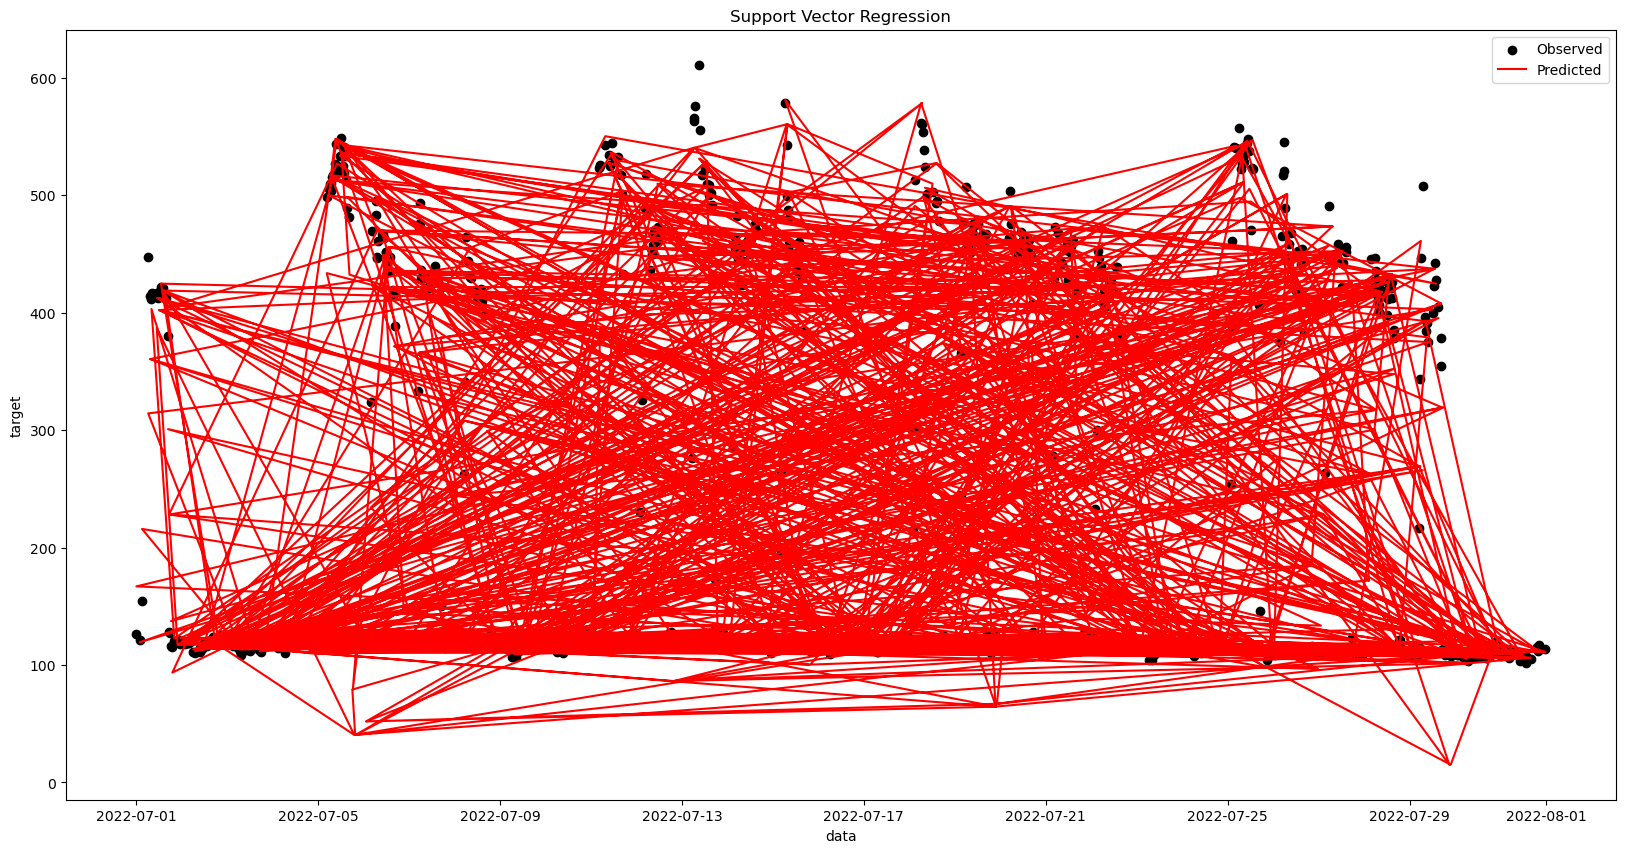

Text(0.5, 1.0, 'Predicted vs Actual Energy Use: $Y_i$ vs $\\hat{Y}_i$')

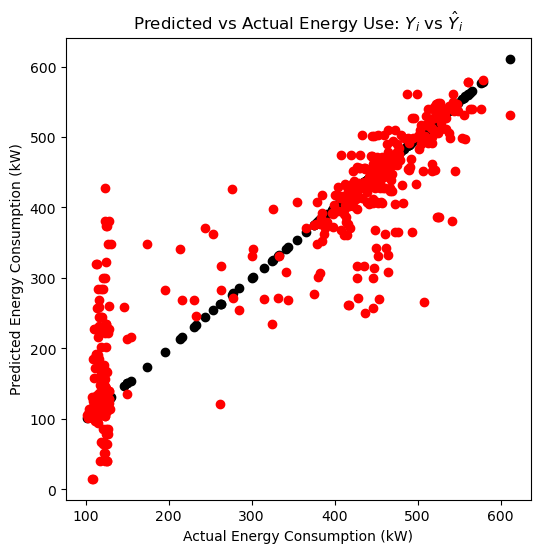

In [24]:
# Visualize Data
# Plot observed and predicted energy values (actual data points vs svm)
fig,ax = plt.subplots(1, 1,figsize=(20,10))
plt.scatter(x_test.index, y_test, c='k', label='Observed')
plt.plot(x_test.index, y_predict, c='r', label='Predicted')
plt.xlabel('data')
plt.ylabel('target')
plt.title('Support Vector Regression')
plt.legend()
plt.show()

# Plot Observed vs Predicted (line of best fit chart)
fig = plt.figure(figsize=(6,6))
plt.scatter(y_test, y_test, c='k')
plt.scatter(y_test, y_predict, c='r')
plt.xlabel('Actual Energy Consumption (kW)')
plt.ylabel("Predicted Energy Consumption (kW)")
plt.title("Predicted vs Actual Energy Use: $Y_i$ vs $\hat{Y}_i$")

Principal Component Analysis

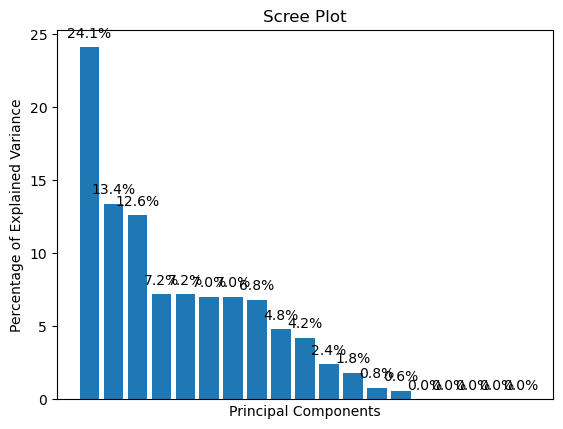

In [25]:
pca = PCA() # By default PCA() centers the data, but does not scale it
X_train_pca = pca.fit_transform(X_train_scaled)

per_var = np.round(pca.explained_variance_ratio_ * 100, decimals= 1)
labels = [str(x) for x in range(1, len(per_var) + 1)]

plt.bar(x = range(1, len(per_var) +1) , height=per_var)
plt.tick_params(
    axis ='x',               
    which = 'both',
    bottom = False,
    top = False,
    labelbottom = False)

for i, value in enumerate(per_var):
    plt.text(i + 1.0, value + 0.7, f'{value}%', ha='center')


plt.ylabel('Percentage of Explained Variance')
plt.xlabel('Principal Components')
plt.title('Scree Plot')
plt.show()

In [26]:
train_pc1_coords = X_train_pca[: , 0]
train_pc2_coords = X_train_pca[: , 1]

# pc1 contains the x-axis coordinates of the data after PCA
# pc2 contains the y-axis coordinates of the data after PCA

pca_train_scaled = scale(np.column_stack((train_pc1_coords, train_pc2_coords)))

svr2 = GridSearchCV(SVR(), param_grid = tuned_parameters, verbose = 0)

modelSVR2 = svr2.fit(pca_train_scaled, np.ravel(y_train))

print(svr2.best_params_)


{'C': 2001, 'epsilon': 0.1, 'gamma': 0.001, 'kernel': 'rbf'}
